In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [3]:
df = df[df['room_type'] == 'Shared room']

In [455]:
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
15885 non-null  object
dtypes: object(1)
memory usage: 248.2+ KB


In [456]:
df['property_type'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: property_type
Non-Null Count  Dtype 
--------------  ----- 
15885 non-null  object
dtypes: object(1)
memory usage: 248.2+ KB


In [4]:
df['price'] = df['price'].astype(float)

In [5]:
df['property_type'] = df['property_type'].str.replace('Shared room in rental unit', '1', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in loft', '1.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in guesthouse', '2', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in hostel', '2.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in home', '3', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in guest suite', '3.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in dorm', '4', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in condo', '4.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in hotel', '5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in tiny home', '5.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in cabin', '6', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in serviced apartment', '6.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in tent', '7', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in bed and breakfast', '7.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in casa particular', '8', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in townhouse', '8.5', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in farm stay', '9', regex=False)
df['property_type'] = df['property_type'].str.replace('Shared room in boutique hotel', '9.5', regex=False)

In [15]:
df['property_type'] = df['property_type'].astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_40776\1104701643.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


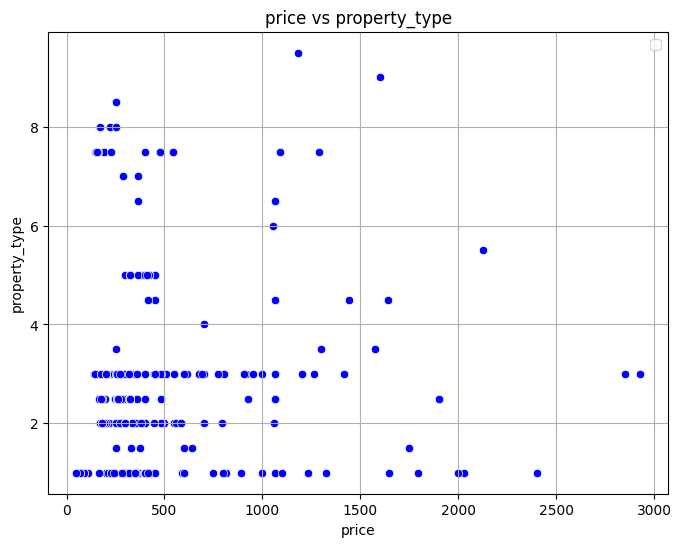

In [16]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='property_type', x='price',  color = 'blue', data=df)
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
indep= df[['property_type']]
dep = df[['price']]

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [19]:
model.fit(indep, dep)

LinearRegression()

In [20]:
type(model)

sklearn.linear_model._base.LinearRegression

In [21]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[-1.23143514]]),
 'rank_': 1,
 'singular_': array([36.41005383]),
 'intercept_': array([443.55548789])}

In [22]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[-1.23143514]]
Intercepto: [443.55548789]
y = [-1.23143514]x + [443.55548789]


In [23]:
r2 = model.score(indep, dep)
r2

2.995666577132461e-05

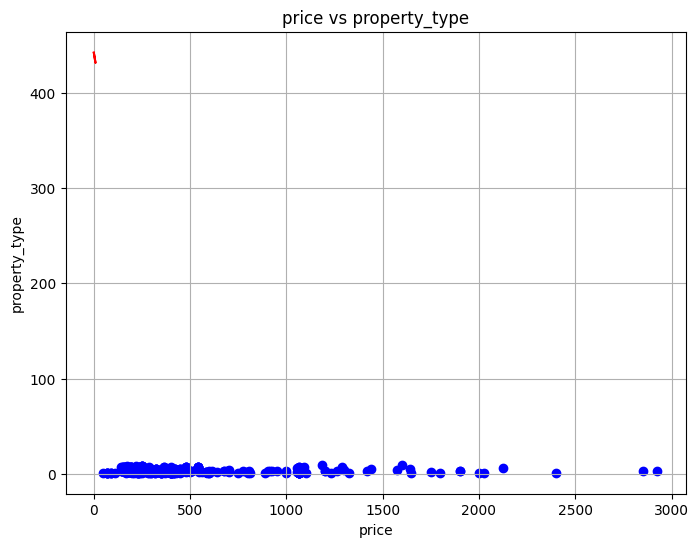

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.grid(True)
plt.show()

In [25]:
yPred = model.predict(df[['property_type']])
yPred

array([[442.32405275],
       [441.70833518],
       [441.0926176 ],
       [440.47690003],
       [439.86118246],
       [442.32405275],
       [440.47690003],
       [442.32405275],
       [440.47690003],
       [439.86118246],
       [439.86118246],
       [442.32405275],
       [439.24546489],
       [439.86118246],
       [439.86118246],
       [442.32405275],
       [442.32405275],
       [439.86118246],
       [442.32405275],
       [442.32405275],
       [442.32405275],
       [439.24546489],
       [442.32405275],
       [439.86118246],
       [438.62974732],
       [439.24546489],
       [439.86118246],
       [442.32405275],
       [442.32405275],
       [440.47690003],
       [440.47690003],
       [440.47690003],
       [440.47690003],
       [440.47690003],
       [442.32405275],
       [438.01402975],
       [440.47690003],
       [442.32405275],
       [439.86118246],
       [440.47690003],
       [440.47690003],
       [440.47690003],
       [440.47690003],
       [440

In [26]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
114,115,617137,3059169,1,1,previous scrape,Apt near Mexico City's downtown,No description,No neighborhood_overview,Andoni,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,0.135,442.324053
257,258,3197924,16186468,2,2,city scrape,cuarto con terraza y uso general,"double bed , full bathroom, room with own terr...",Condesa is the main attraction in the city for...,Jordi,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.195,441.708335
365,366,5434219,28190065,18,1,city scrape,メキシコシティの革命記念塔付近のホステルです。,Single Room $30<br />Double room $60<br />Dorm...,No neighborhood_overview,Tetsuo,...,2.0,4.44,4.74,4.47,4.74,4.71,4.71,4.59,0.300,441.092618
443,444,6972071,35406862,16,1,city scrape,SUPER SAVER GROUP DEAL - PERFECT FOR STUDENTS,Welcome to the best college-style dorms in a B...,No neighborhood_overview,Thor,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,0.165,440.476900
455,456,6076798,31426842,12,1,city scrape,Nova House,It has all the comforts to rest if you come fo...,The neighborhood is popular where you can expe...,Antonio,...,0.0,4.85,4.84,4.93,4.94,4.91,4.69,4.93,0.750,439.861182


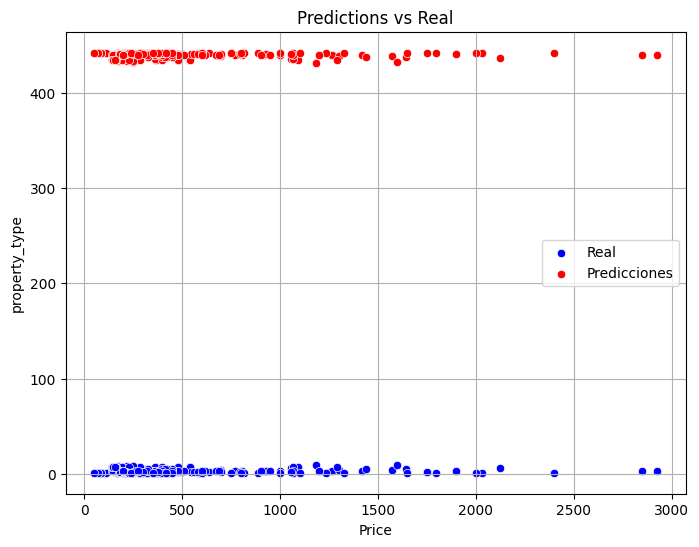

In [27]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='property_type', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
coefDe = model.score(indep, dep)
coefDe

2.995666577132461e-05

In [29]:
coefDe = model.score(indep, dep)
coefDe

2.995666577132461e-05

In [30]:
df = df[df['host_acceptance_rate'] != 'No data']
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)

In [31]:
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_40776\1234139552.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)


In [34]:
df['bathrooms_text'].head()

257    1.5 
365      8 
443      4 
455      3 
536      5 
Name: bathrooms_text, dtype: object

In [33]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared baths', '', regex=False)
#df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared baths', '', regex=False)
#df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared', '', regex=False)


In [35]:
df = df.dropna(subset=['bathrooms_text'])
df['bathrooms_text'] = pd.to_numeric(df['bathrooms_text'], errors='coerce')
df['bathrooms_text'] = df['bathrooms_text'].astype(float)

In [37]:
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)

In [38]:
df['instant_bookable'] = df['instant_bookable'].replace({'t': 1, 'f': 0}).astype(int)

C:\Users\issei\AppData\Local\Temp\ipykernel_40776\4229115140.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].replace({'t': 1, 'f': 0}).astype(int)


In [39]:
df = df[['host_acceptance_rate','host_is_superhost','price','accommodates','bathrooms_text','review_scores_cleanliness','host_identity_verified','instant_bookable','host_total_listings_count','review_scores_value','reviews_per_month','property_type']]

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340 entries, 257 to 26560
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   host_acceptance_rate       340 non-null    float64
 1   host_is_superhost          340 non-null    float64
 2   price                      340 non-null    float64
 3   accommodates               340 non-null    float64
 4   bathrooms_text             196 non-null    float64
 5   review_scores_cleanliness  340 non-null    float64
 6   host_identity_verified     340 non-null    int32  
 7   instant_bookable           340 non-null    int32  
 8   host_total_listings_count  340 non-null    float64
 9   review_scores_value        340 non-null    float64
 10  reviews_per_month          340 non-null    float64
 11  property_type              340 non-null    float64
dtypes: float64(10), int32(2)
memory usage: 31.9 KB


In [41]:
correlacion = df.corr()
correlacion

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.220812,0.076800,0.114553,-0.361120,-0.020618,-0.238387,0.639902,0.324846,-0.027566,-0.068995,0.117123
host_is_superhost,0.220812,1.000000,0.004881,-0.071500,0.009435,0.113015,0.149838,-0.001087,-0.011758,0.162748,0.262066,-0.162949
price,0.076800,0.004881,1.000000,0.191204,-0.272394,-0.013270,0.038389,0.035139,-0.080681,0.000504,-0.080693,0.019638
accommodates,0.114553,-0.071500,0.191204,1.000000,-0.123686,-0.066361,0.199577,-0.002551,-0.198974,-0.097295,0.036891,0.063538
bathrooms_text,-0.361120,0.009435,-0.272394,-0.123686,1.000000,0.091790,0.171725,-0.341104,0.094712,-0.012905,0.038751,-0.038806
review_scores_cleanliness,-0.020618,0.113015,-0.013270,-0.066361,0.091790,1.000000,-0.126921,-0.091400,-0.024187,0.529634,0.026769,0.068983
host_identity_verified,-0.238387,0.149838,0.038389,0.199577,0.171725,-0.126921,1.000000,-0.334778,0.179500,-0.047499,0.058288,0.066033
instant_bookable,0.639902,-0.001087,0.035139,-0.002551,-0.341104,-0.091400,-0.334778,1.000000,0.247390,-0.032311,-0.111841,0.145649
host_total_listings_count,0.324846,-0.011758,-0.080681,-0.198974,0.094712,-0.024187,0.179500,0.247390,1.000000,-0.009495,-0.071365,0.143719
review_scores_value,-0.027566,0.162748,0.000504,-0.097295,-0.012905,0.529634,-0.047499,-0.032311,-0.009495,1.000000,0.033510,0.107591


In [42]:
corr = abs(correlacion)
corr

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.220812,0.076800,0.114553,0.361120,0.020618,0.238387,0.639902,0.324846,0.027566,0.068995,0.117123
host_is_superhost,0.220812,1.000000,0.004881,0.071500,0.009435,0.113015,0.149838,0.001087,0.011758,0.162748,0.262066,0.162949
price,0.076800,0.004881,1.000000,0.191204,0.272394,0.013270,0.038389,0.035139,0.080681,0.000504,0.080693,0.019638
accommodates,0.114553,0.071500,0.191204,1.000000,0.123686,0.066361,0.199577,0.002551,0.198974,0.097295,0.036891,0.063538
bathrooms_text,0.361120,0.009435,0.272394,0.123686,1.000000,0.091790,0.171725,0.341104,0.094712,0.012905,0.038751,0.038806
review_scores_cleanliness,0.020618,0.113015,0.013270,0.066361,0.091790,1.000000,0.126921,0.091400,0.024187,0.529634,0.026769,0.068983
host_identity_verified,0.238387,0.149838,0.038389,0.199577,0.171725,0.126921,1.000000,0.334778,0.179500,0.047499,0.058288,0.066033
instant_bookable,0.639902,0.001087,0.035139,0.002551,0.341104,0.091400,0.334778,1.000000,0.247390,0.032311,0.111841,0.145649
host_total_listings_count,0.324846,0.011758,0.080681,0.198974,0.094712,0.024187,0.179500,0.247390,1.000000,0.009495,0.071365,0.143719
review_scores_value,0.027566,0.162748,0.000504,0.097295,0.012905,0.529634,0.047499,0.032311,0.009495,1.000000,0.033510,0.107591


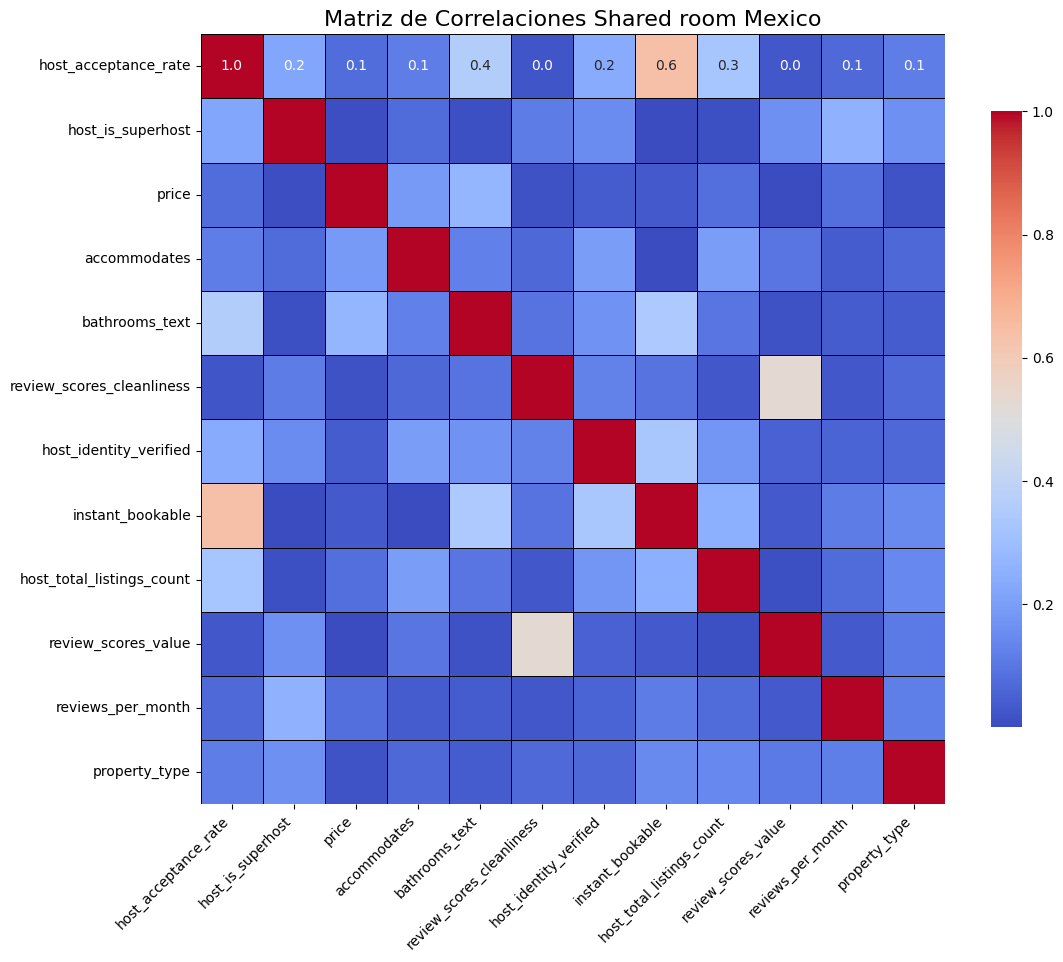

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.5, linecolor='black', cbar_kws={'shrink': 0.8}, annot_kws={"size": 10})
plt.title('Matriz de Correlaciones Shared room Mexico', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()